Producto escalar (a . b): -5.32
Multiplicación punto a punto: [  3.1    3.    -1.1  -16.32   6.  ]

Matriz Transpuesta A^T:
 [[ 2.   4.   7.3]
 [-1.   1.5 -0.9]
 [-3.  -2.5  0.2]]

Demostración NumPy:
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
round: [-2.  1.  2.  4.]
ceil: [-1.  2.  3.  4.]
floor: [-2.  1.  2.  3.]

Elemento Fila 1, Columna 3: -3.0
Segunda fila de A: [ 4.   1.5 -2.5]
Dimensiones de A: (3, 3)


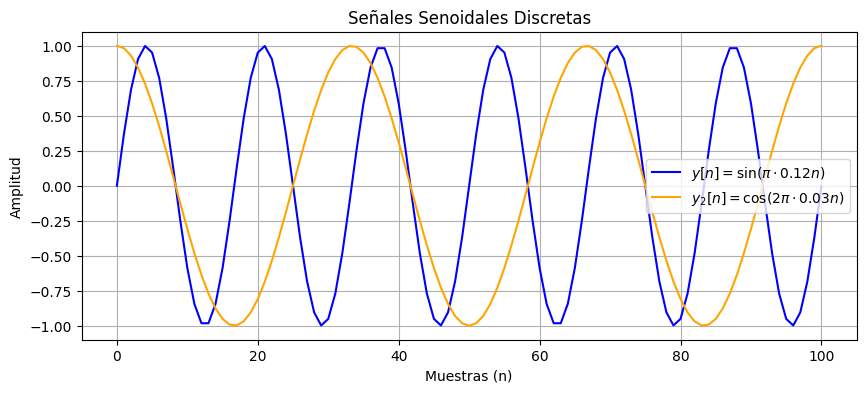

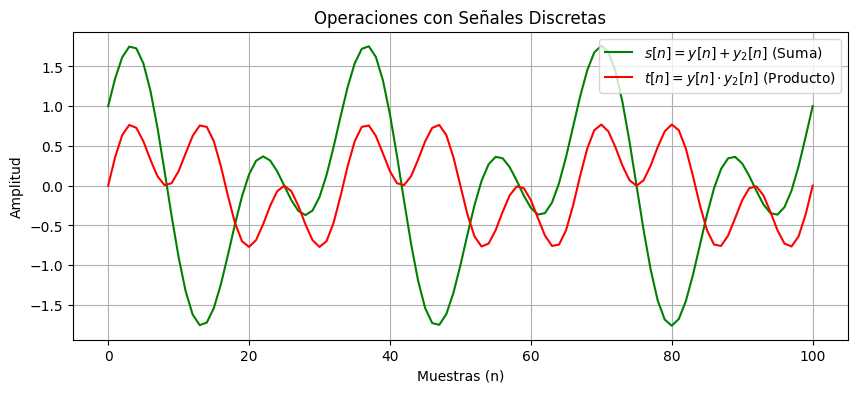

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Vectores
a = np.array([3.1, 1, -0.5, -3.2, 6])
b = np.array([1, 3, 2.2, 5.1, 1])

# Multiplicación escalar (Producto punto dot product)
# Para realizar producto escalar a.b, los vectores deben ser arrays de NumPy o usarse np.dot().
producto_escalar = np.dot(a, b)
print(f"Producto escalar (a . b): {producto_escalar}")

# Multiplicación elemento a elemento
producto_punto_a_punto = a * b
print(f"Multiplicación punto a punto: {producto_punto_a_punto}")

# Matriz A
A = np.array([
    [2, -1, -3],
    [4, 1.5, -2.5],
    [7.3, -0.9, 0.2]
])

AT = A.T
print("\nMatriz Transpuesta A^T:\n", AT)

# Funciones de NumPy
# np.ones: Genera un arreglo lleno de unos.
# np.round: Redondea al entero/decimal más cercano.
# np.ceil: Redondea hacia arriba (techo).
# np.floor: Redondea hacia abajo (piso).

arr_ones = np.ones((2, 3))
arr_ejemplo = np.array([-1.7, 1.2, 2.5, 3.8])

print("\nDemostración NumPy:")
print("ones:\n", arr_ones)
print("round:", np.round(arr_ejemplo))
print("ceil:", np.ceil(arr_ejemplo))
print("floor:", np.floor(arr_ejemplo))

# Accesos e inspección de A
elem_1_3 = A[0, 2] # Fila 1 (índice 0), Columna 3 (índice 2)
segunda_fila = A[1, :]
dimensiones = A.shape

print(f"\nElemento Fila 1, Columna 3: {elem_1_3}")
print(f"Segunda fila de A: {segunda_fila}")
print(f"Dimensiones de A: {dimensiones}")

# Señales Senoidales
n = np.arange(0, 101)
y1_n = np.sin(np.pi * 0.12 * n)
y2_n = np.cos(2 * np.pi * 0.03 * n)

s_n = y1_n + y2_n
t_n = y1_n * y2_n

# Gráfica 1: y[n] y y2[n]
plt.figure(figsize=(10, 4))
plt.plot(n, y1_n, label=r'$y[n] = \sin(\pi \cdot 0.12 n)$', color='blue')
plt.plot(n, y2_n, label=r'$y_2[n] = \cos(2\pi \cdot 0.03 n)$', color='orange')
plt.title('Señales Senoidales Discretas')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica 2: s[n] y t[n]
plt.figure(figsize=(10, 4))
plt.plot(n, s_n, label=r'$s[n] = y[n] + y_2[n]$ (Suma)', color='green')
plt.plot(n, t_n, label=r'$t[n] = y[n] \cdot y_2[n]$ (Producto)', color='red')
plt.title('Operaciones con Señales Discretas')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1935/4178975038.py:42: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Derivada Discreta $\Delta x[n]$')


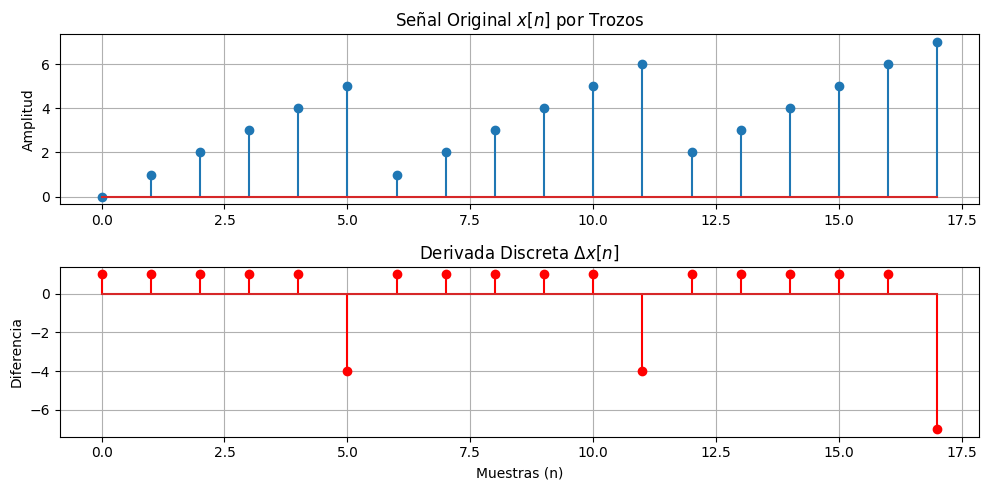

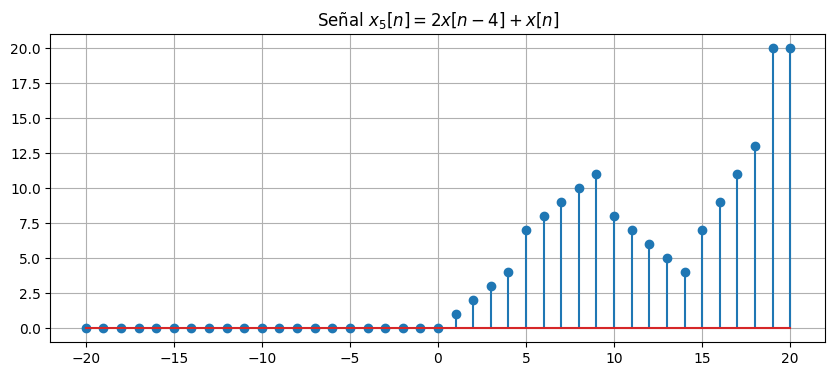

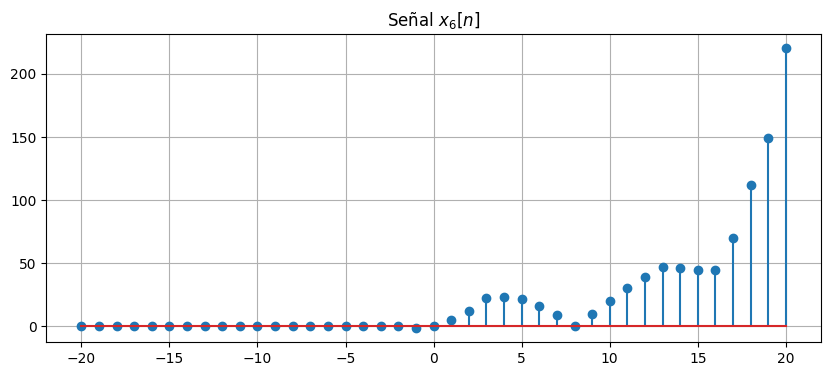

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# funciones elementales
def impseq(n0, n1, n2):
    n = np.arange(n1, n2 + 1)
    x = (n - n0) == 0
    return x.astype(int), n

def stepseq(n0, n1, n2):
    n = np.arange(n1, n2 + 1)
    x = (n - n0) >= 0
    return x.astype(int), n

def rampseq(n0, n1, n2, m=1):
    n = np.arange(n1, n2 + 1)
    x = m * (n - n0) * ((n - n0) >= 0)
    return x, n

# derivada discreta y concatenacion de senales

# Secuencia x[n] por trozos
n_tot = np.arange(0, 18)
r_a, _ = rampseq(0, 0, 5)
r_b, _ = rampseq(5, 6, 11)
r_c, _ = rampseq(10, 12, 17)

x_seg = np.concatenate([r_a, r_b, r_c])

# Derivada discreta
dx = np.diff(x_seg, append=0)

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.stem(n_tot, x_seg)
plt.title('Señal Original $x[n]$ por Trozos')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(n_tot, dx, linefmt='r-', markerfmt='ro')
plt.title('Derivada Discreta $\Delta x[n]$')
plt.xlabel('Muestras (n)')
plt.ylabel('Diferencia')
plt.grid(True)
plt.tight_layout()
plt.show()

# Secuencia x_base concatenada
x_base = np.array([0,1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10])
n_eval = np.arange(-20, 21)

def get_signal_val(x_arr, n_origin, n_range):
    y = np.zeros(len(n_range))
    for idx, val in enumerate(x_arr):
        target_n = n_origin + idx
        pos = np.where(n_range == target_n)[0]
        if len(pos) > 0:
            y[pos[0]] = val
    return y

x_n = get_signal_val(x_base, 0, n_eval)
x_n_shift4 = get_signal_val(x_base, 4, n_eval) # x[n-4]

# x5[n] = 2*x[n-4] + x[n]
x5 = 2 * x_n_shift4 + x_n

# x6[n]
x_n_plus1 = get_signal_val(x_base, -1, n_eval)
x_n_plus2 = get_signal_val(x_base, -2, n_eval)
x6 = (0.001 * np.exp(0.5 * n_eval) * x_n_plus1) + (10 * np.sin(0.05 * np.pi * n_eval) * x_n_plus2)

plt.figure(figsize=(10, 4))
plt.stem(n_eval, x5)
plt.title(r'Señal $x_5[n] = 2x[n-4] + x[n]$')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.stem(n_eval, x6)
plt.title(r'Señal $x_6[n]$')
plt.grid(True)
plt.show()

In [1]:
#Repaso Pandas

import pandas as pd
import numpy as np

# 1) Funcion de estadísticas de notas de alumnos
def calcular_estadisticas_notas(notas_dict):
    serie_notas = pd.Series(notas_dict)
    return pd.Series({
        'mínima': serie_notas.min(),
        'máxima': serie_notas.max(),
        'media': serie_notas.mean(),
        'desviación típica': serie_notas.std()
    })

notas_alumnos = {'Ana': 4.5, 'Carlos': 3.2, 'Beatriz': 2.8, 'David': 5.0}
print("Estadísticas de notas:")
print(calcular_estadisticas_notas(notas_alumnos))


# Calculo del indice de Masa Corporal (IMC)

# Carga de datos
df = pd.read_csv("datos.csv", sep=';')

# primeras y ultimas filas
print("\n--- Primeras filas ---")
print(df.head())

print("\n--- Últimas filas ---")
print(df.tail())

# Borrar la columna "Unnamed: 0"
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Convertir columnas numéricas por seguridad ante valores faltantes
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')

# Calcular el IMC y agregar columna "BMI"
# IMC = Peso (kg) / (Altura (m))^2
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# Categorizar a los participantes según su IMC
def categorizar_imc(imc):
    if pd.isna(imc):
        return np.nan
    elif imc < 18.5:
        return 'Bajo peso'
    elif 18.5 <= imc <= 24.9:
        return 'Normal'
    elif 25 <= imc <= 29.9:
        return 'Sobrepeso'
    else:
        return 'Obesidad'

df['Categoria_IMC'] = df['BMI'].apply(categorizar_imc)

print("\n--- DataFrame Resultante ---")
print(df.head())

Estadísticas de notas:
mínima               2.800000
máxima               5.000000
media                3.875000
desviación típica    1.043631
dtype: float64

--- Primeras filas ---
   Unnamed: 0  Gender  FSIQ  VIQ  PIQ  Weight  Height  MRI_Count
0           1  Female   133  132  124   118.0    64.5     816932
1           3    Male   139  123  150   143.0    73.3    1038437
2           4    Male   133  129  128   172.0    68.8     965353
3           5  Female   137  132  134   147.0    65.0     951545
4           6  Female    99   90  110   146.0    69.0     928799

--- Últimas filas ---
    Unnamed: 0  Gender  FSIQ  VIQ  PIQ  Weight  Height  MRI_Count
33          36  Female   133  129  128   153.0    66.5     948066
34          37    Male   140  150  124   144.0    70.5     949395
35          38  Female    88   86   94   139.0    64.5     893983
36          39    Male    81   90   74   148.0    74.0     930016
37          40    Male    89   91   89   179.0    75.5     935863

--- Data